<a href="https://colab.research.google.com/github/ku59/DN_Proj/blob/main/%EC%B6%9C%EC%82%B0%EC%9C%A8_%EC%8B%9C%EB%AE%AC%EB%A0%88%EC%9D%B4%EC%85%98_%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
            출생아수(명)  여성_카드이용_지수  교육서비스_카드이용_지수  출생아수(명)_lag1  출생아수(명)_lag3  \
월                                                                            
2020-07-01    22999        82.7          117.0       22117.0       23299.0   
2020-08-01    22402        79.9          120.2       22999.0       22847.0   
2020-09-01    23499        79.1           53.0       22402.0       22117.0   
2020-10-01    21884        78.1           62.9       23499.0       22999.0   
2020-11-01    20054        96.8          106.2       21884.0       22402.0   
2020-12-01    19641        84.9           65.4       20054.0       23499.0   
2021-01-01    24894        73.4           64.0       19641.0       21884.0   
2021-02-01    21306        81.9           89.1       24894.0       20054.0   
2021-03-01    23925        93.2          123.5       21306.0       19641.0   
2021-04-01   

<Figure size 800x600 with 0 Axes>

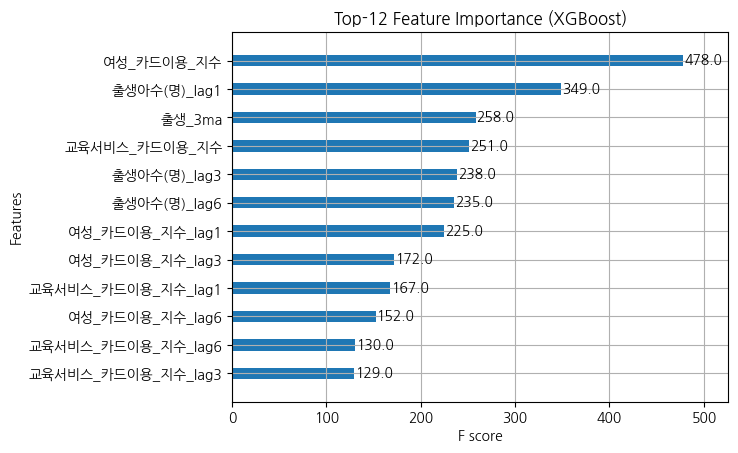


2025-04 기준:
 • baseline 예측  : 21,076 명
 • +20% 시나리오 : 21,109 명
 • 차이           : +33 명


In [17]:
from google.colab import drive
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error


drive.mount('/content/drive')
filepath = '/content/drive/My Drive/exp_data/병합데이터_출산율제거.csv'


df = pd.read_csv(filepath, parse_dates=['월'])
df.sort_values('월', inplace=True)
df.set_index('월', inplace=True)

'''시계열 정보를 보존해야하니 1,3,6개월 lag값을 만들어서 설정했음'''
lags = [1, 3, 6]
for col in ['출생아수(명)', '여성_카드이용_지수', '교육서비스_카드이용_지수']:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)



'''단기 추세를 반영하기 위해서 3개월 이평값 추가했음'''
df['출생_3ma'] = df['출생아수(명)'].rolling(3).mean()


'''
우리나라 출산할때 보면 특정 계절이나 달에 출산하려고 하는 경향이 많이 보여서
이를 반영하기 위해 month, quarter를 원-핫 인코딩 벡터로 추가해봤음..
df['month']   = df.index.month
df['quarter'] = df.index.quarter
df = pd.get_dummies(df, columns=['month', 'quarter'], drop_first=True)
=> 최종 비활성화 결정.. 데이터가 적어서 그런지.. 사용지수 증가에 따라 출생이 증가함..
'''

'''빈 값은 없애버림'''
df.dropna(inplace=True)

pd.set_option('display.max_rows', None)
print(df)

'''학습/검증 분리 (2025-01 이후는 테스트)'''
train = df.loc[:'2024-12']
test  = df.loc['2025-01':]           # 2025-01 ~ 2025-04

X_train = train.drop(columns=['출생아수(명)'])
y_train = train['출생아수(명)']
X_test  = test.drop(columns=['출생아수(명)'])
y_test  = test['출생아수(명)']

'''시계열 전용 교차검증 + 하이퍼파라미터 탐색'''
tscv  = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators'      : [300, 450, 600],
    'learning_rate'     : [0.05, 0.1],
    'max_depth'         : [3, 4],
    'subsample'         : [0.7, 0.9],
    'colsample_bytree'  : [0.7, 0.9],
    'objective'         : ['reg:squarederror']
}

xgb = XGBRegressor(random_state=42)

gscv = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
gscv.fit(X_train, y_train)

print('Best CV MAE:', -gscv.best_score_)
print('Best params:', gscv.best_params_)

'''테스트 구간 예측'''
best_xgb = gscv.best_estimator_
y_pred   = best_xgb.predict(X_test)

print('\nTEST MAE :', mean_absolute_error(y_test, y_pred))
print('TEST RMSE:', mean_squared_error(y_test, y_pred))

'''시각화'''
import matplotlib.pyplot as plt
from xgboost import plot_importance
!pip install koreanize-matplotlib
import koreanize_matplotlib

plt.figure(figsize=(8,6))
plot_importance(best_xgb, max_num_features=12, height=0.4)
plt.title('Top-12 Feature Importance (XGBoost)')
plt.show()

'''What-If 시뮬레이션
지수를 +20% 늘렸을 때 2025-04 예측 변화'''
row      = X_test.loc['2025-03'].copy()
baseline = best_xgb.predict(row.values.reshape(1,-1))[0]

row['여성_카드이용_지수'] *= 1.20
row['교육서비스_카드이용_지수'] *= 1.20
scenario = best_xgb.predict(row.values.reshape(1,-1))[0]

print(f"\n2025-04 기준:")
print(f" • baseline 예측  : {baseline:,.0f} 명")
print(f" • +20% 시나리오 : {scenario:,.0f} 명")
print(f" • 차이           : {scenario-baseline:+,.0f} 명")